In [19]:
df.head(40)

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,"June 1, 2020",TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ..."
7,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",R,119 min,Dramas,After one of his high school students attacks ...
8,s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,"April 1, 2019",TV-14,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w..."
9,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,"December 15, 2017",TV-MA,143 min,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

print("=== Sesi 1: Data Wrangling ===")

df = pd.read_csv('Netflix Dataset.csv')
print(f"Ukuran awal dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

df.drop_duplicates(subset=['Show_Id'], inplace=True)
print(f"Ukuran setelah data duplikat dihapus: {df.shape[0]} baris")

df_movies = df[df['Category'] == 'Movie'].copy()

df_movies.dropna(subset=['Duration'], inplace=True)

df_movies['Duration_Num'] = df_movies['Duration'].str.extract('(\d+)').astype(int)
print(f"Jumlah data 'Movie' yang siap dianalisis: {df_movies['Duration_Num'].shape[0]} baris")

=== Sesi 1: Data Wrangling ===
Ukuran awal dataset: 7789 baris, 11 kolom
Ukuran setelah data duplikat dihapus: 7787 baris
Jumlah data 'Movie' yang siap dianalisis: 5377 baris


<>:30: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:30: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Digitalisasi\AppData\Local\Temp\ipykernel_13520\1735096042.py:30: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_movies['Duration_Num'] = df_movies['Duration'].str.extract('(\d+)').astype(int)


In [23]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [14]:
print("\n=== 40 baris Data Movies (Sudah Bersih) ===")
print(df_movies[['Show_Id', 'Category', 'Title', 'Duration', 'Duration_Num']].head(40))


=== 40 baris Data Movies (Sudah Bersih) ===
   Show_Id Category                          Title Duration  Duration_Num
1       s2    Movie                          07:19   93 min            93
2       s3    Movie                          23:59   78 min            78
3       s4    Movie                              9   80 min            80
4       s5    Movie                             21  123 min           123
6       s7    Movie                            122   95 min            95
7       s8    Movie                            187  119 min           119
8       s9    Movie                            706  118 min           118
9      s10    Movie                           1920  143 min           143
10     s11    Movie                           1922  103 min           103
13     s14    Movie                          2,215   89 min            89
14     s15    Movie                           3022   91 min            91
15     s16    Movie                         Oct-01  149 min        

In [9]:
print("\n=== Sesi 2: Analisis Deskriptif & Skewness ===")

mean_dur = df_movies['Duration_Num'].mean()
median_dur = df_movies['Duration_Num'].median()
mode_dur = df_movies['Duration_Num'].mode()[0]
skew_coef = df_movies['Duration_Num'].skew()

print(f"Mean (Rata-rata) Durasi : {mean_dur:.2f} menit")
print(f"Median (Nilai Tengah)    : {median_dur:.2f} menit")
print(f"Modus (Sering Muncul)    : {mode_dur:.2f} menit")
print(f"Koefisien Skewness       : {skew_coef:.4f}")

if skew_coef > 0:
    skew_type = "Positive Skewness (Miring Kanan)"
    reasoning = "Ekor kurva memanjang ke kanan. Mayoritas film Netflix berdurasi pendek-sedang, namun ada beberapa film dengan durasi sangat panjang (ekstrem)."
elif skew_coef < 0:
    skew_type = "Negative Skewness (Miring Kiri)"
    reasoning = "Ekor kurva memanjang ke kiri. Mayoritas film Netflix berdurasi panjang, namun ada beberapa film berdurasi sangat singkat (ekstrem)."
else:
    skew_type = "Symmetric Distribution (Normal)"
    reasoning = "Kurva seimbang, distribusi film berdurasi ideal merata."

print(f"Kesimpulan Bentuk Data   : {skew_type}")
print(f"Alasan Karakteristik     : {reasoning}")


=== Sesi 2: Analisis Deskriptif & Skewness ===
Mean (Rata-rata) Durasi : 99.31 menit
Median (Nilai Tengah)    : 98.00 menit
Modus (Sering Muncul)    : 90.00 menit
Koefisien Skewness       : 0.1910
Kesimpulan Bentuk Data   : Positive Skewness (Miring Kanan)
Alasan Karakteristik     : Ekor kurva memanjang ke kanan. Mayoritas film Netflix berdurasi pendek-sedang, namun ada beberapa film dengan durasi sangat panjang (ekstrem).


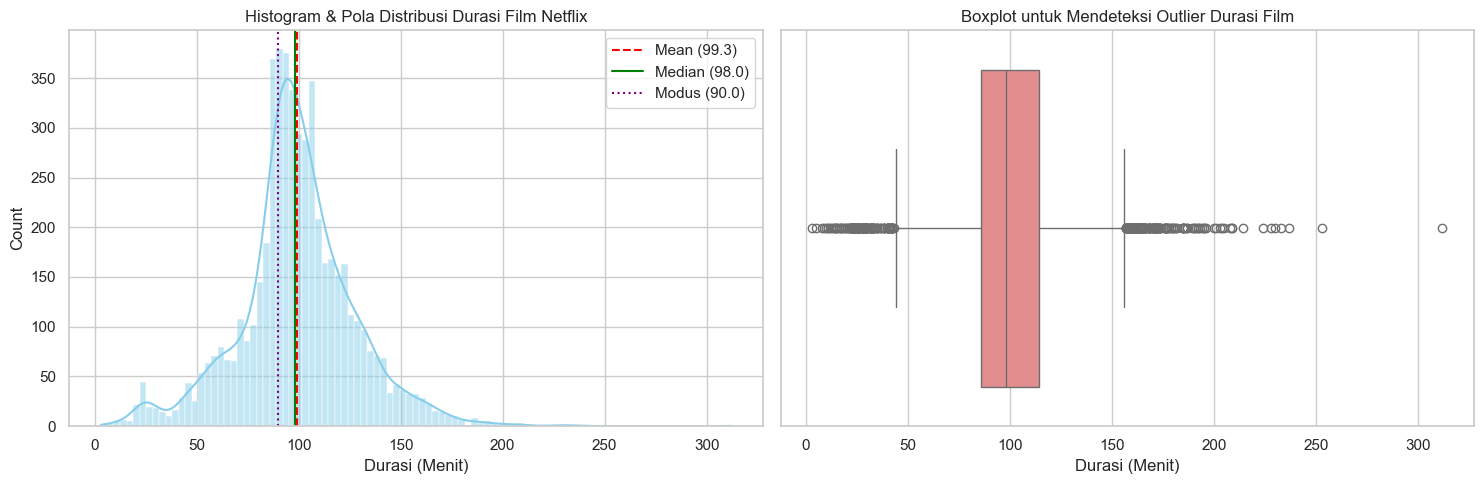

In [11]:
# Visualisasi Histogram dan Boxplot Original
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(df_movies['Duration_Num'], kde=True, color='skyblue', ax=axes[0])
axes[0].axvline(mean_dur, color='red', linestyle='--', label=f'Mean ({mean_dur:.1f})')
axes[0].axvline(median_dur, color='green', linestyle='-', label=f'Median ({median_dur:.1f})')
axes[0].axvline(mode_dur, color='purple', linestyle=':', label=f'Modus ({mode_dur:.1f})')
axes[0].set_title('Histogram & Pola Distribusi Durasi Film Netflix')
axes[0].set_xlabel('Durasi (Menit)')
axes[0].legend()

sns.boxplot(x=df_movies['Duration_Num'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot untuk Mendeteksi Outlier Durasi Film')
axes[1].set_xlabel('Durasi (Menit)')

plt.tight_layout()
plt.show()


=== Sesi 3: Distribusi Probabilitas & Simulasi Monte Carlo ===


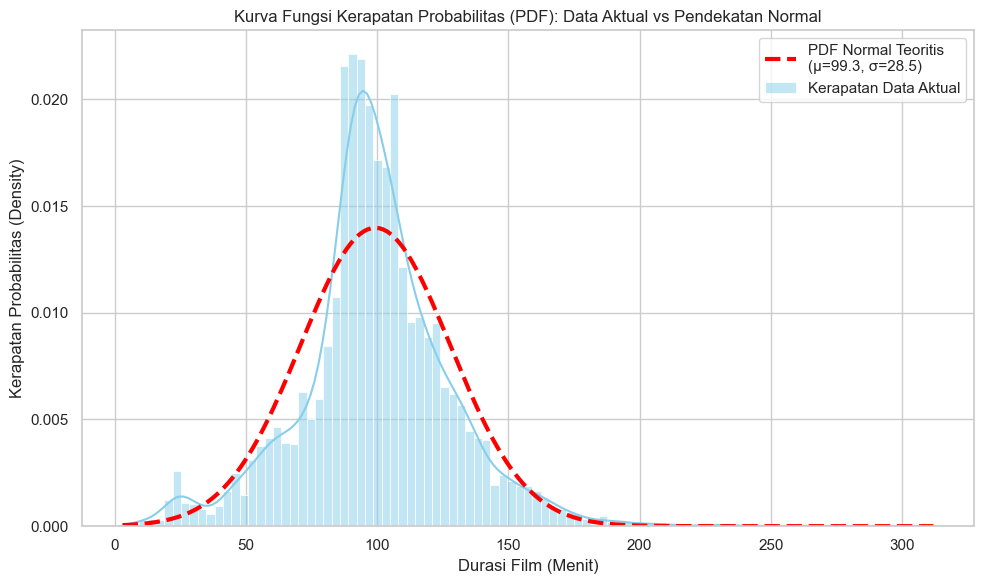

In [12]:
print("\n=== Sesi 3: Distribusi Probabilitas & Simulasi Monte Carlo ===")

std_dur = df_movies['Duration_Num'].std()

plt.figure(figsize=(10, 6))

sns.histplot(df_movies['Duration_Num'], kde=True, stat="density", color='skyblue', label='Kerapatan Data Aktual')

x_axis = np.linspace(df_movies['Duration_Num'].min(), df_movies['Duration_Num'].max(), 200)
pdf_normal = stats.norm.pdf(x_axis, mean_dur, std_dur)
plt.plot(x_axis, pdf_normal, color='red', linewidth=3, linestyle='--', 
         label=f'PDF Normal Teoritis\n(μ={mean_dur:.1f}, σ={std_dur:.1f})')

plt.title('Kurva Fungsi Kerapatan Probabilitas (PDF): Data Aktual vs Pendekatan Normal')
plt.xlabel('Durasi Film (Menit)')
plt.ylabel('Kerapatan Probabilitas (Density)')
plt.legend()
plt.tight_layout()
plt.show()


--- Menjalankan Simulasi Monte Carlo ---
Simulasi Monte Carlo berhasil dijalankan sebanyak 1000 iterasi.
Proyeksi rata-rata keseluruhan durasi film masa depan: 99.34 menit


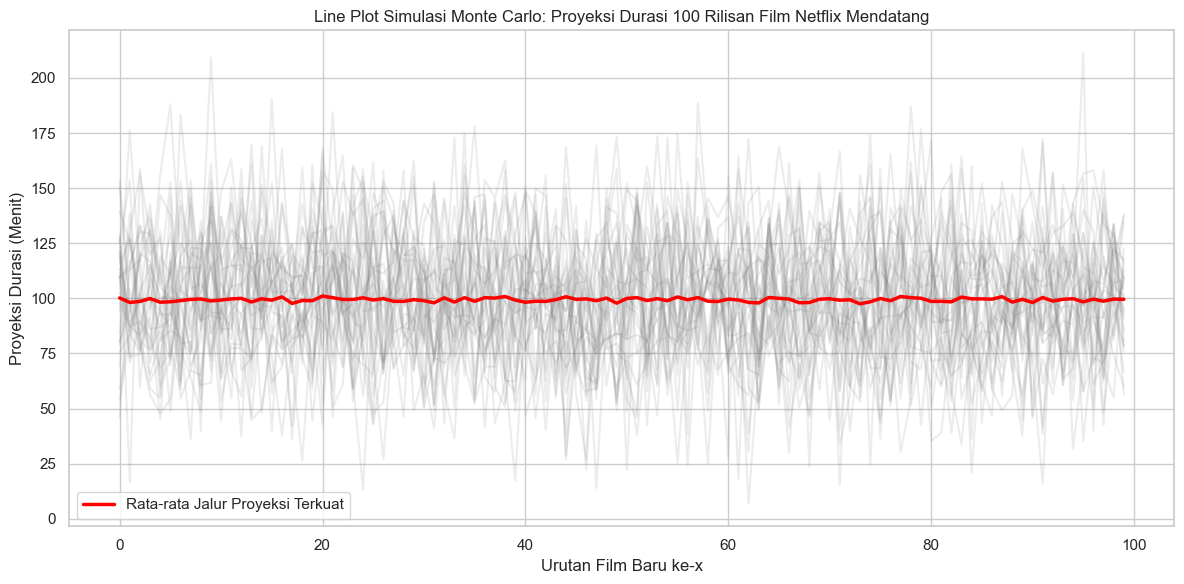

In [13]:
print("\n--- Menjalankan Simulasi Monte Carlo ---")
jumlah_proyeksi_film = 100
jumlah_simulasi = 1000 

hasil_simulasi = np.zeros((jumlah_proyeksi_film, jumlah_simulasi))

np.random.seed(42) 
for i in range(jumlah_simulasi):
    hasil_simulasi[:, i] = np.random.normal(loc=mean_dur, scale=std_dur, size=jumlah_proyeksi_film)

print(f"Simulasi Monte Carlo berhasil dijalankan sebanyak {jumlah_simulasi} iterasi.")
print(f"Proyeksi rata-rata keseluruhan durasi film masa depan: {np.mean(hasil_simulasi):.2f} menit")

plt.figure(figsize=(12, 6))
plt.plot(hasil_simulasi[:, :30], alpha=0.15, color='gray') 
plt.plot(np.mean(hasil_simulasi, axis=1), color='red', linewidth=2.5, label='Rata-rata Jalur Proyeksi Terkuat')
plt.title('Line Plot Simulasi Monte Carlo: Proyeksi Durasi 100 Rilisan Film Netflix Mendatang')
plt.xlabel('Urutan Film Baru ke-x')
plt.ylabel('Proyeksi Durasi (Menit)')
plt.legend()
plt.tight_layout()
plt.show()